# Disease Vectors Analogical Reasoning

In this notebook, we show how to use our model to compute disease vectors.  quantify how related they are analogically. 

In [ ]:
DISEASES_DICT = {'respiratory': [ 'COVID-19', 'influenza', 'lung adenocarcinoma'], 'neurological': ['Alzheimer disease', 'Parkinson disease', 'glioblastoma']}

EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/'
cell_type_dict = {
                "respiratory": ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell', 'classical monocyte',
                 'B cell' 'natural killer cell'],
                 
                 "neurological": ['neuron', 'microglial cell', 'oligodendrocyte', 'astrocyte',]
                 }
tissue_type_dict = {
                "respiratory": ["blood"],
                 "neurological": ["brain"]
                 }

import sys
sys.path.append("../../../")
import warnings; warnings.filterwarnings("ignore")

import json
import scanpy as sc
from tqdm import tqdm
from polygene.model.model import load_trained_model
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

model, tokenizer = load_trained_model("../../../runs/gesam_polygene_run_4/", checkpoint_n=-1)
diseases = json.load(open(EMBEDDINGS_DIR + 'diseases.json'))['diseases']

In [ ]:
N_CHUNKS = 500
dataset_path='/media/rohola/ssd_storage/primary/'

import functools, operator
from itertools import product
from braceexpand import braceexpand
from anndata import read_h5ad, concat
from polygene.data_utils.tokenization import normalise_str

age_map = pd.read_csv('../../data_utils/age_relabeling.csv')
age_map = {v[0]:v[1] for v in age_map[['label', 'age']].values.tolist()}

def get_adult(x):
    val = age_map.get(normalise_str(x['development_stage']))
    if pd.isna(val): print('Error', x['development_stage'])
    return "yes" if val//10 >= 6 else "no"

import functools, operator
from itertools import product
from braceexpand import braceexpand
from anndata import read_h5ad, AnnData, concat
from tqdm import tqdm

def get_phenotype_cells(
    paths: list,
    n: int = 1,
    match_other_phenotypes: bool = False,
    get_info: bool = False,
    phenotypes_to_add: dict = None,
    **phenotypes
):
    """
    Get N cells with a specific phenotype.

    n: number of cells per phenotype combination
    paths: list of braceexpandable paths to h5ad files
    phenotypes: dict like sex=['M'], tissue=['blood']
    """
    processed_paths = [path for bracepath in paths for path in braceexpand(bracepath)]
    cells = []

    combination_types = list(phenotypes)
    required = {phenotype_combination: n for phenotype_combination in product(*phenotypes.values())}

    for path in tqdm(processed_paths):
        if not len(required):
            break

        anndata = read_h5ad(path, backed=None)  # fully loaded; could use backed="r" if big
        if phenotypes_to_add is not None:
            for phenotype in phenotypes_to_add:
                anndata.obs[phenotype] = anndata.obs.apply(lambda x: phenotypes_to_add[phenotype](x), axis=1)

        mask = functools.reduce(operator.and_, (
            anndata.obs[phenotypic_type].isin(value)
            for phenotypic_type, value in phenotypes.items()
            if phenotypic_type in anndata.obs.columns
        ))
        filtered_anndata = anndata[mask]

        if get_info:
            print(filtered_anndata.obs[list(phenotypes.keys())].value_counts())

        for combination in list(required.keys()):
            submask = functools.reduce(operator.and_, (
                filtered_anndata.obs[phenotypic_type] == value
                for phenotypic_type, value in zip(combination_types, combination)
            ))
            subset = filtered_anndata[submask][:required[combination]]

            if subset.n_obs > 0:
                # rebuild a compact AnnData, drop raw/layers if present
                compact = AnnData(X=subset.X.copy(), obs=subset.obs.copy(), var=subset.var.copy())
                compact.raw = None
                compact.layers.clear()
                cells.append(compact)

                required[combination] -= subset.n_obs
                if required[combination] < 1:
                    del required[combination]

            del submask, subset
        del anndata, filtered_anndata, mask

    result = concat(cells) if len(cells) else AnnData()
    print(f"Loaded {result.n_obs} cells\n")
    return result


for category in DISEASES_DICT: 
    cells = get_phenotype_cells(paths=[dataset_path + f'cxg_chunk{{2502..{2502+N_CHUNKS}}}.h5ad'], n=100, phenotypes_to_add={'adult':get_adult}, disease=['normal'] + DISEASES_DICT[category], sex=['male','female'], tissue_general=tissue_type_dict[category], 
                                cell_type=cell_type_dict[category], adult=['yes'])
    cells.obs.index.name = None
    cells.write(EMBEDDING_DIR + f'{category}_cells.h5ad')
    del cells

100%|██████████| 501/501 [05:16<00:00,  1.58it/s]


Loaded 1474 cells



100%|██████████| 501/501 [05:29<00:00,  1.52it/s]


Loaded 2321 cells



In [2]:
import torch
from polygene.eval.metrics import prepare_cell
embeddings, predictions, labels = ([] for _ in range(3))
cells = sc.concat([sc.read_h5ad(EMBEDDING_DIR + f'{category}_cells.h5ad') for  category in DISEASES_DICT])
for cell in tqdm(cells, "Embeddings"):
    cell_dict = prepare_cell(cell, tokenizer) # gets it in the right ModelInput format
    cell_dict['input_ids'][np.arange(1, 1+len(tokenizer.phenotypic_types))] = 2 # id of mask token
    with torch.no_grad():
        output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items() if key != 'str_labels'})

    encoder_output = output.hidden_states # tensor shape (B, S, D)
    embeddings.append(encoder_output[:, 0])
    labels.append(cell_dict['str_labels'][1:1+len(tokenizer.phenotypic_types)])
    predictions.append([tokenizer.flattened_tokens[output.logits.argmax(dim=-1).squeeze()[1+idx]] for idx in range(len(tokenizer.phenotypic_types))])

embeddings = (torch.cat(embeddings).detach().cpu().numpy(), np.array(predictions), np.array(labels))
pd.to_pickle(embeddings, EMBEDDING_DIR + "embeddings.pkl")

Embeddings: 100%|██████████| 3795/3795 [00:49<00:00, 77.02it/s] 


In [3]:
from sklearn.decomposition import PCA
embeddings = pd.read_pickle(EMBEDDING_DIR + f'embeddings.pkl')
cells = np.concatenate([PCA(256).fit_transform(sc.read_h5ad(EMBEDDING_DIR + f'{category}_cells.h5ad').X.toarray()) for  category in DISEASES_DICT])

df = pd.DataFrame({'embedding': embeddings[0].tolist(), 'y_pred': embeddings[1].tolist(), "raw": cells.tolist()}
                   | {tokenizer.phenotypic_types[idx]:embeddings[2][:, idx] for idx in range(len(tokenizer.phenotypic_types))})
df[['disease', 'cell_type']]= df[['disease', 'cell_type']].applymap(lambda x: ' '.join([word for word in x[1:-1].split('_')]))
df.sample()

,embedding,y_pred,raw,assay,cell_type,development_stage,disease,sex,tissue
1158,"[-3.1106793880462646, -1.3066285848617554, -5....","[[10x_3_v3], [classical_monocyte], [68_year_ol...","[20.58989715576172, 5.0632710456848145, 1.2733...",[10x_3_v3],classical monocyte,[68_year_old_human_stage],influenza,[male],[blood]


In [13]:
print(tokenizer.phenotypic_types)
(np.array(embeddings[1]) == np.array(embeddings[2])).mean(axis=0).round(3)

['assay', 'cell_type', 'development_stage', 'disease', 'sex', 'tissue']


array([1.   , 0.942, 0.771, 0.893, 0.955, 0.928])

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
reducer = umap.UMAP(spread=1, min_dist=0.1, n_neighbors=15, random_state=3,)
reducer = TSNE(2, perplexity=150, random_state=3)
reducer = PCA(2)
df[['UMAP1', 'UMAP2']] = reducer.fit_transform(np.array(df['embedding'].tolist()))

In [5]:
import umap
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine

def cosine_sim(a, b):
    return 1 - cosine(a, b)


def plot_umap(df, disease_label, labels, palette_dict, reduction='umap', figure_size=(8,6),
                marker_size=40, save_path=None, alpha=0.6, lw=0,
                fontsize=12, SAVE=False):

    
    fig, ax = plt.subplots(figsize=figure_size, dpi=300 if SAVE else 100)

    sns.scatterplot(data=df, x='UMAP1', y='UMAP2', hue=labels, palette=palette_dict, s=40, alpha=0.8, ax=ax, linewidth=0.1, edgecolor='k', zorder=1)
    ax.set_axisbelow(True)
    disease_vectors = []
    for cell_type in df['cell_type'].unique():
        normal_cells = df[(df['disease'] == 'normal') & (df['cell_type'] == cell_type)]
        disease_cells = df[(df['disease'] == disease_label) & (df['cell_type'] == cell_type)]
        if len(normal_cells) > 0 and len(disease_cells) > 0:
            normal_centroid = normal_cells[['UMAP1','UMAP2']].mean().values
            disease_centroid = disease_cells[['UMAP1','UMAP2']].mean().values
            vector = disease_centroid - normal_centroid
            disease_vectors.append(vector)
            Q = ax.quiver(normal_centroid[0], normal_centroid[1],
                        disease_centroid[0] - normal_centroid[0],
                        disease_centroid[1] - normal_centroid[1],
                        angles='xy', scale_units='xy', scale=1,
                        width=0.008, headwidth=4, headlength=6, headaxislength=4,
                        linewidth=.01, color='black')
        
    from matplotlib.patches import FancyArrowPatch
    from matplotlib.legend_handler import HandlerPatch
    arrow_proxy = FancyArrowPatch((0, 0), (1, 0),
                              arrowstyle='-|>',  # same style as quiver
                              mutation_scale=15, # head size
                              color='black',
                            linewidth=1)
    def make_legend_quiver(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
        return FancyArrowPatch((0, height*0.5), (width, height*0.5),
                            arrowstyle='-|>',
                            mutation_scale=fontsize,  # scales with legend font size
                            color='black',
                            linewidth=1)


    r = cosine_sim(disease_vectors[0], disease_vectors[1])
    handles, legend_labels_ = ax.get_legend_handles_labels()
    handles.append(arrow_proxy)
    legend_labels_.append(f"Disease Vectors ($\\rho$={r:.2f})")
    palette_order = list(palette_dict.keys())

    order = sorted(
        range(len(handles)-1),
        key=lambda i: palette_order.index(legend_labels_[i])
    ) + [len(handles)-1]
    legend_labels_ = [' '.join([word.capitalize() for word in x.replace(' disease', '').split(' ')]) for x in legend_labels_]
    ax.legend(np.array(handles)[order].tolist(), np.array(legend_labels_)[order].tolist(),frameon=True, loc='upper left', borderaxespad=1, edgecolor='lightgrey', framealpha=0.9, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_quiver)}
              , fontsize=fontsize-2)
    for legend_handle in ax.legend_.legendHandles:
        legend_handle.set_alpha(1)

    #ax.set_xticks([]); ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', linewidth=0.2, alpha=0.5, color='k',zorder=0)

    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_linewidth(2)
    ax.set_xlabel(f'{reduction.upper()}1', fontsize=fontsize)
    ax.set_ylabel(f'{reduction.upper()}2', fontsize=fontsize)
    ax.set_xlim(df['UMAP1'].quantile(.01)- 1, df['UMAP1'].quantile(.99)+1)
    ax.set_ylim(df['UMAP2'].quantile(.01)- 1, df['UMAP2'].quantile(.99)+1)
    plt.tight_layout()
    if SAVE:
        plt.savefig(SAVE_PATH + f'{df["disease"].unique().tolist()[1]}_vector_{reduction}.png', dpi=300, transparent=True)
        plt.savefig(SAVE_PATH + f'{df["disease"].unique().tolist()[1]}_vector_{reduction}.svg', dpi=300, transparent=True)
    plt.show()

reduction='pc'
#for disease_label in df['disease'].unique().tolist():
#    if disease_label == 'normal': continue
#    ds = df[(df['disease'].isin([disease_label, 'normal'])) & (df['cell_type'].isin(df[df['disease'] == disease_label]['cell_type'].unique().tolist()[:2]))]
#    labels = ds.apply(lambda x: x['disease'] + ' ' + x['cell_type'], axis=1)
#
#    palette_dict = {f"{cond} {' '.join([w for w in c.split('_')])}": sns.color_palette('Paired', 30)[2*i + j]
#                    for i, c in enumerate(ds['cell_type'].unique()) for j, cond in enumerate(["normal", disease_label])}
#    plot_umap(ds, labels, palette_dict, figure_size=(8,6), reduction=reduction, fontsize=14)

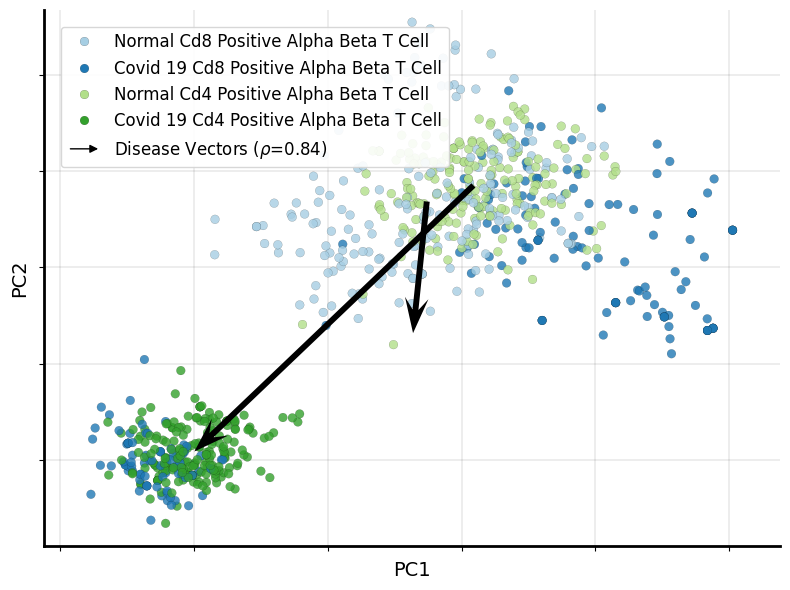

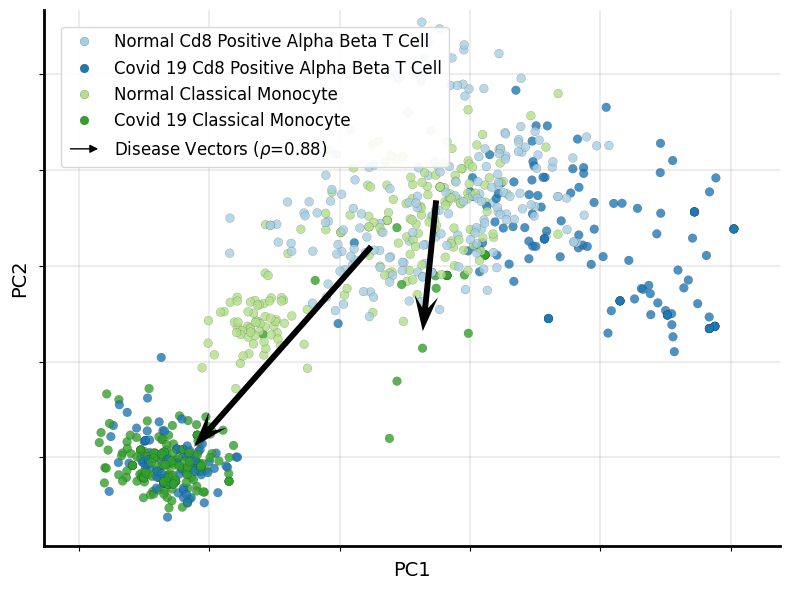

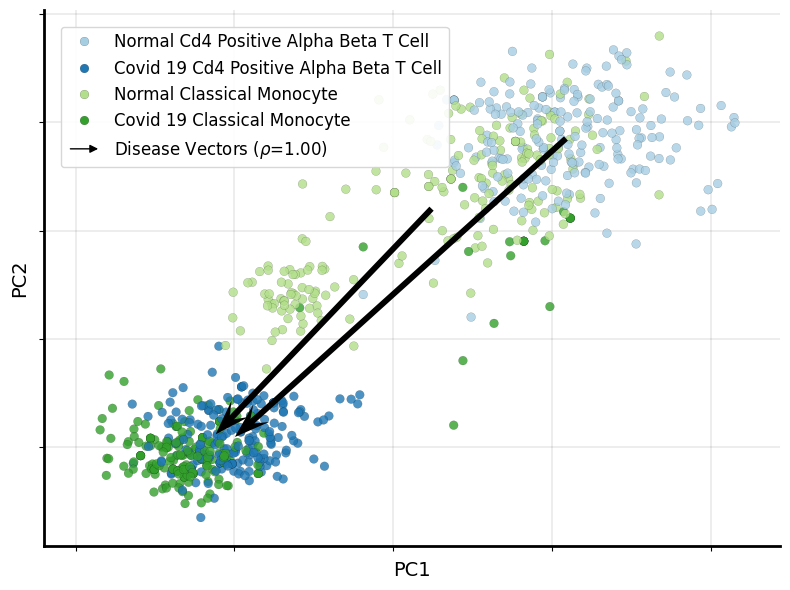

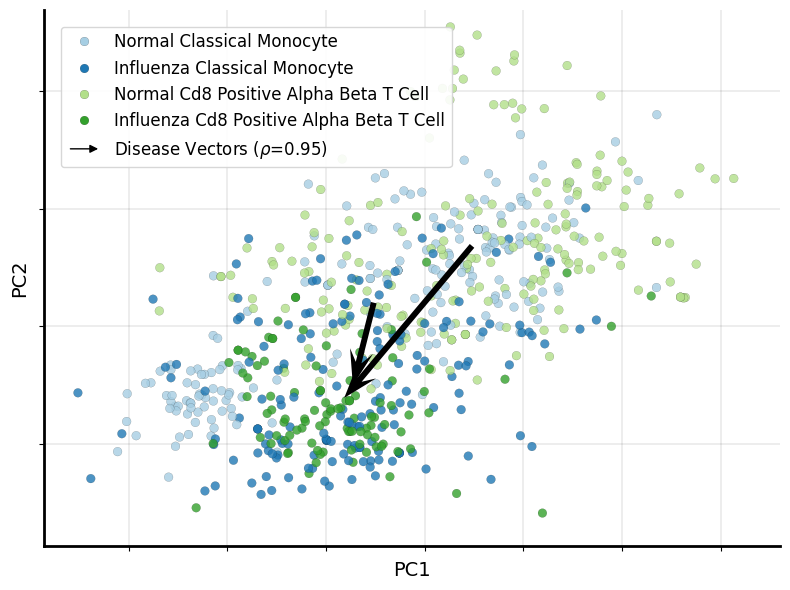

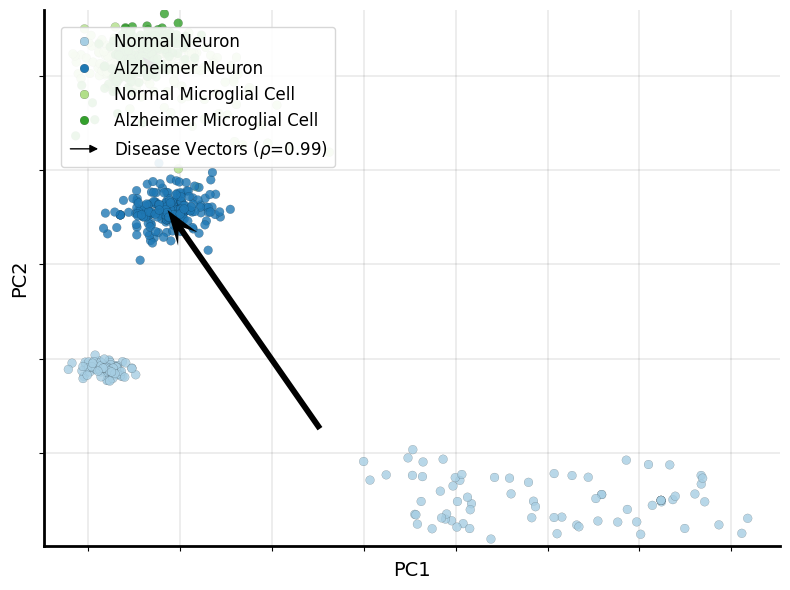

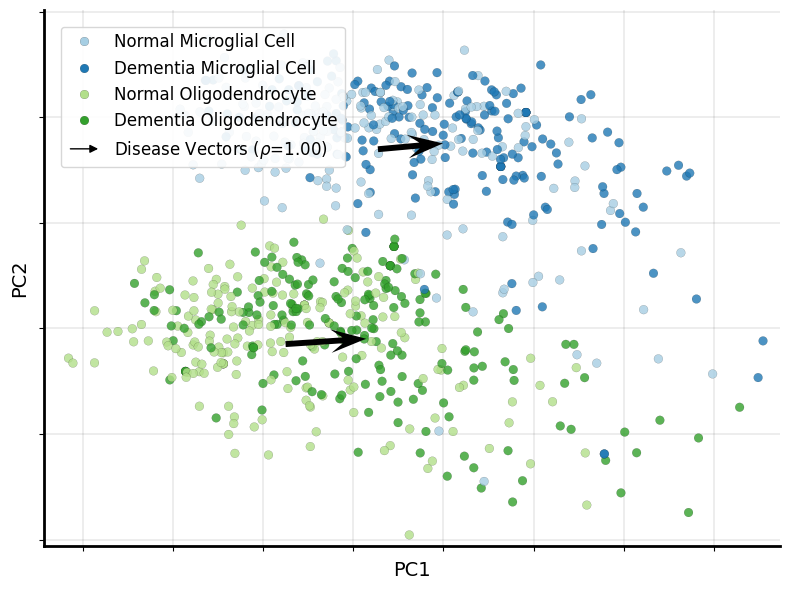

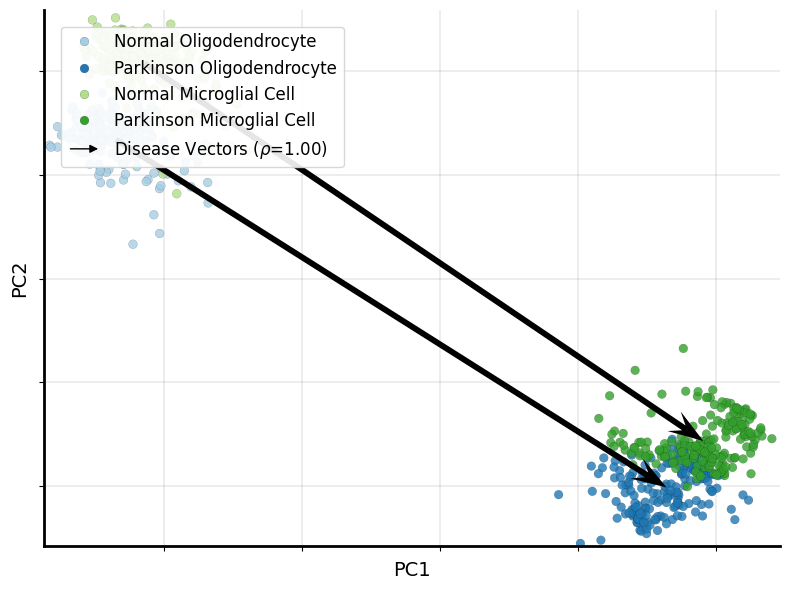

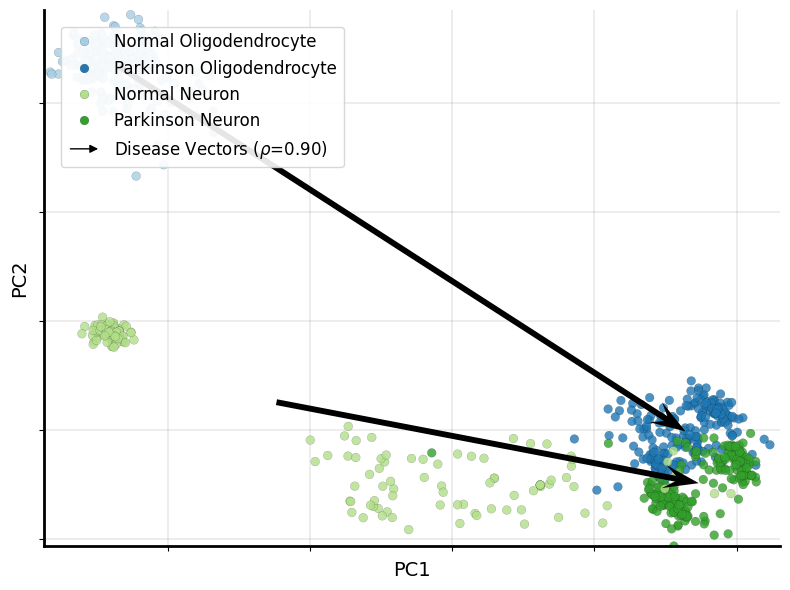

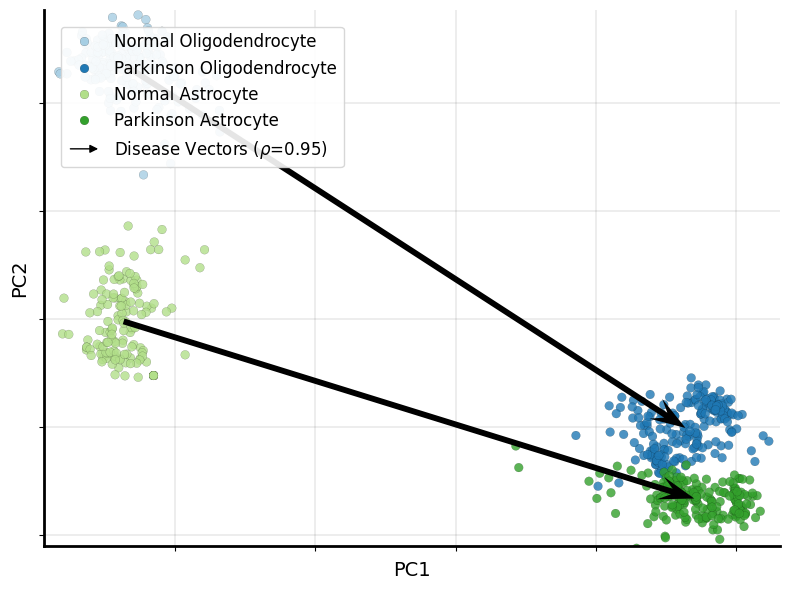

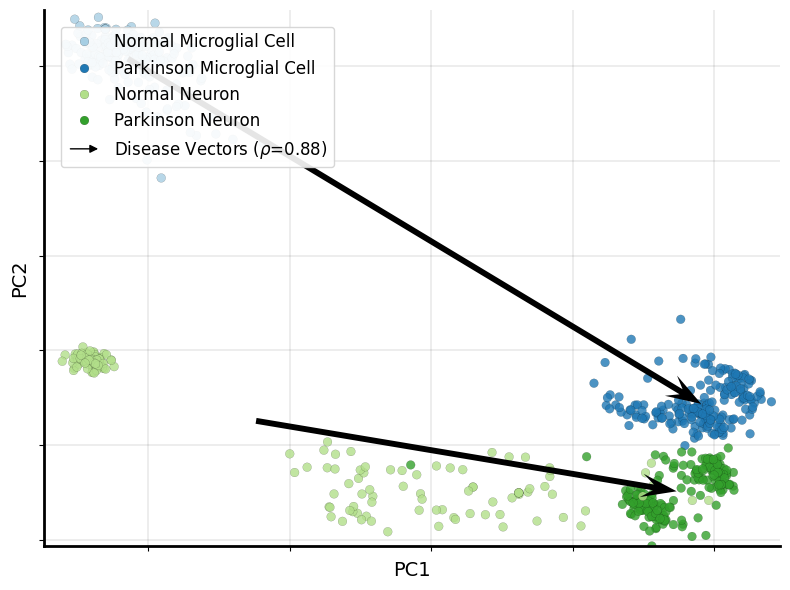

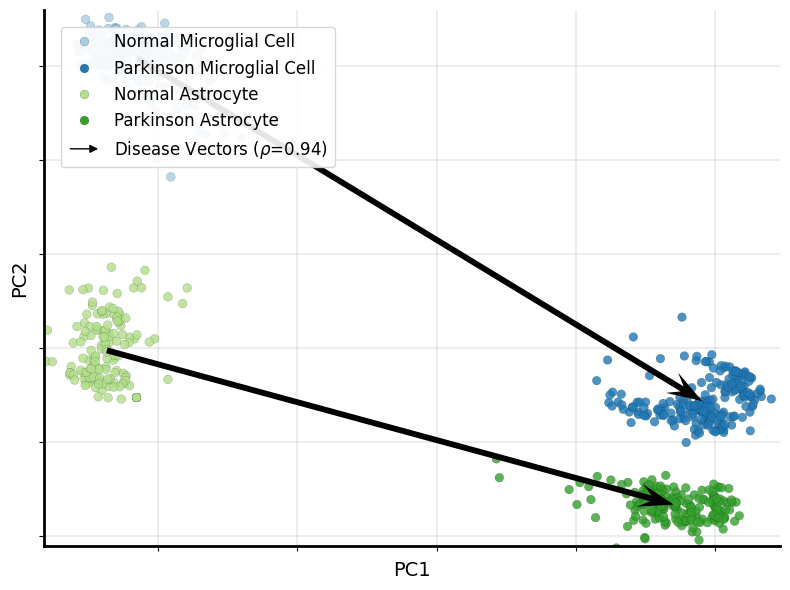

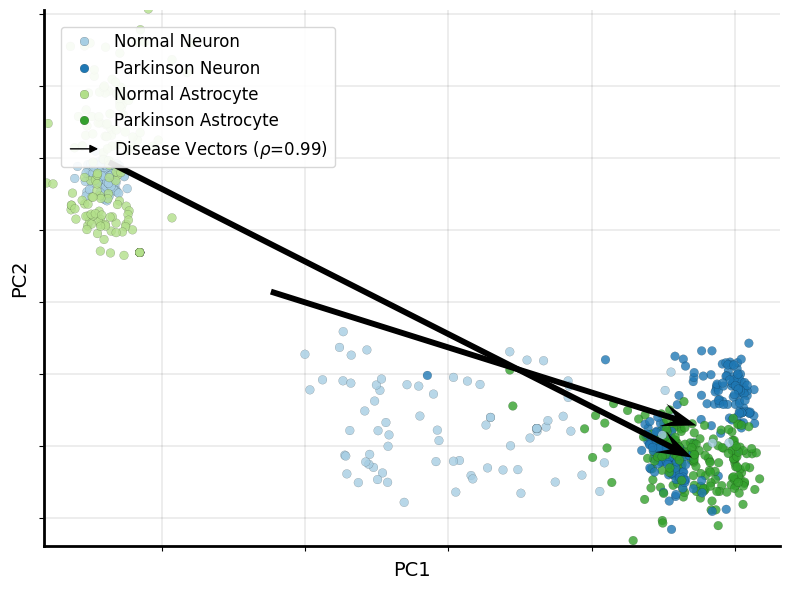

In [6]:
import itertools
import seaborn as sns

for disease_label in df['disease'].unique().tolist():
    if disease_label == 'normal':
        continue
    disease_cell_types = df[df['disease'] == disease_label]['cell_type'].unique().tolist()
    for cell_type_pair in itertools.combinations(disease_cell_types, 2):
        ds = df[(df['disease'].isin([disease_label, 'normal'])) & (df['cell_type'].isin(cell_type_pair))]
        labels = ds.apply(lambda x: f"{x['disease']} {x['cell_type']}", axis=1)

        palette_dict = {f"{cond} {' '.join(c.split('_'))}": sns.color_palette('Paired', 30)[2*i + j]
                        for i, c in enumerate(cell_type_pair) for j, cond in enumerate(["normal", disease_label])}

        plot_umap(ds, disease_label, labels, palette_dict, figure_size=(8, 6), reduction=reduction, fontsize=14)

In [10]:
cell_types = df[df['disease'] == 'normal']['cell_type'].unique().tolist()

disease_vectors = {}
disease_vectors_raw = {}
for cell in cell_types:
    diseases = df[df['cell_type'] == cell]['disease'].unique()
    for d in diseases:
        if d == 'normal': continue
        for type, dict_ in zip(['raw', 'embedding'], [disease_vectors_raw, disease_vectors]):
            a = np.array(df[(df['cell_type'] == cell) & (df['disease']==d)][type].tolist())[:50]
            b = np.array(df[(df['cell_type'] == cell) & (df['disease']=='normal')][type].tolist())[:50]
            #if a.shape[0] < 50 or b.shape[0] < 50: continue
            dict_[d+ "_" +cell.split(' ')[0]] = (a[:, None, :] - b[None, :, :]).reshape(-1, a.shape[1]).tolist()
disease_vectors = pd.DataFrame(disease_vectors)
disease_vectors_raw = pd.DataFrame(disease_vectors_raw)

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from polygene.data_utils.tokenization import normalise_str
from tqdm import tqdm

mean = lambda x: x.mean()
quantile90 = lambda x: np.quantile(x, 0.90)
quantile10 = lambda x: np.quantile(x, 0.10)

functions = [mean]#, quantile90, quantile10]

similarity_results = []
for vectors in tqdm([disease_vectors, disease_vectors_raw]):
    order = sorted(vectors.columns, key=lambda x: [' '.join([word for word in normalise_str(disease)[1:-1].split('_')]) for  disease in sum(DISEASES_DICT.values(), [])].index(x.split("_")[0]))
    raw_similarity = {
        (a, b): cosine_similarity(np.array(vectors[a].tolist()), np.array(vectors[b].tolist()))
        for a in vectors.columns for b in vectors.columns
    }
    for function in functions:
        similarity = [[function(raw_similarity[a, b]) for b in vectors.columns] for a in vectors.columns]
        similarity_df = pd.DataFrame(similarity, index=vectors.columns, columns=vectors.columns)
        mat = similarity_df.loc[order, order]
        similarity_results.append((vectors, function, mat))

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:37<00:00, 18.64s/it]


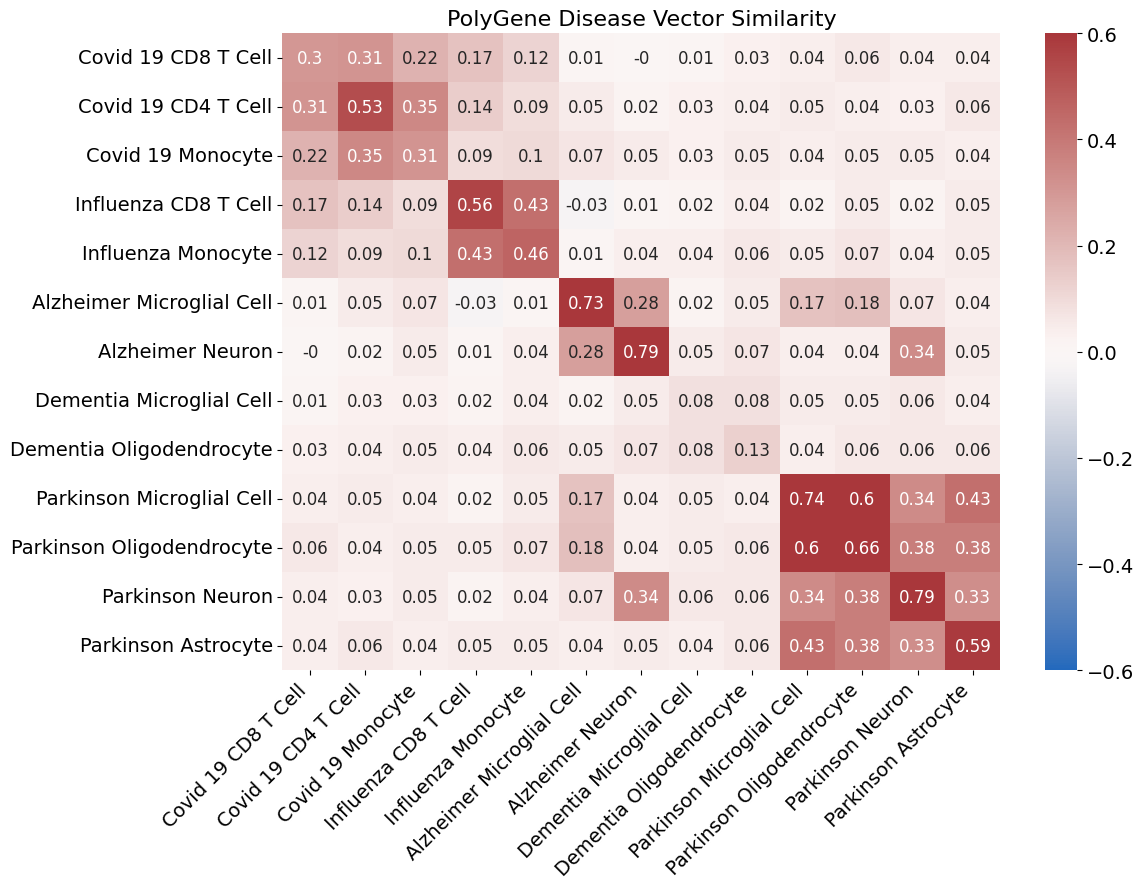

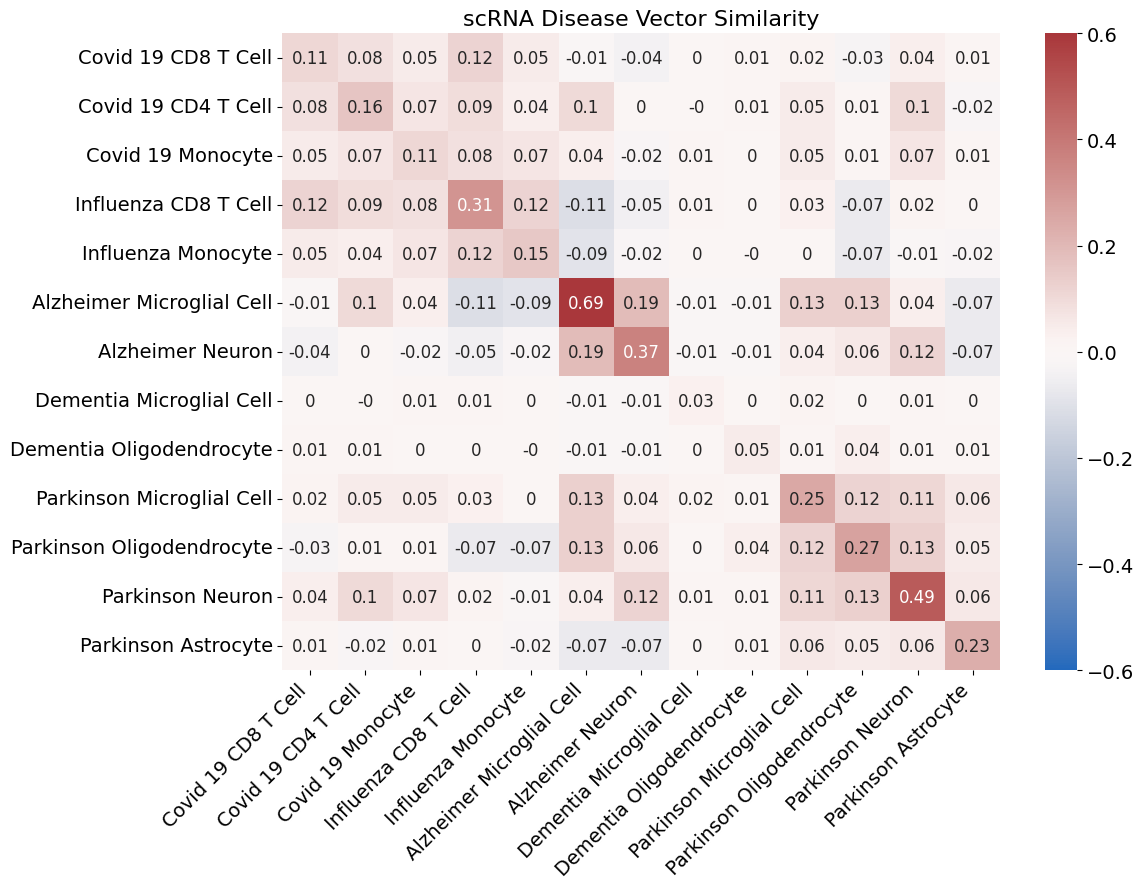

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

SAVE = False
length = 7+2
fontsize = 14

func_names = {mean: "Mean"}#, quantile90: "Q90", quantile10: "Q10"}
similarity_results_2 = [result for result in similarity_results if func_names[result[1]] == 'Mean']
for idx, (vectors, func, mat) in enumerate(similarity_results_2):
    fig, ax = plt.subplots(1, 1, figsize=(length*1 + 3, length), dpi=300 if SAVE else 100)
    if func_names[func] != "Mean": continue
    norm = TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=0.5)
    sns.heatmap(mat.round(2), annot=True, cmap="vlag", vmin=-0.6, vmax=0.6,# center=0,#,#norm=norm,
                xticklabels=mat.columns.tolist(), yticklabels=mat.index.tolist(),
                annot_kws={"size": 12}, ax=ax)
    labels = [' '.join([word.capitalize().replace('Cd8', 'CD8 T Cell').replace('Cd4', 'CD4 T Cell').replace(' disease', '').replace('Classical', 'Monocyte').replace('Microglial', 'Microglial Cell') for word in x.split('_')])for x in mat.columns.tolist()]
    ax.set_xticklabels(labels, rotation=45, fontsize=fontsize, ha='right')
    ax.set_yticklabels(labels, rotation=0, fontsize=fontsize)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=fontsize)

    vec_name = "PolyGene Disease Vector Similarity" if vectors is disease_vectors else "scRNA Disease Vector Similarity"
    ax.set_title(f"{vec_name}", fontsize=fontsize+2)
    plt.tight_layout()
    if SAVE:
        plt.savefig(SAVE_PATH + f"{vec_name.split(' ')[0]}_cosine_matrix.png", transparent=True, dpi=300)
        #plt.savefig(SAVE_PATH + f"{vec_name.split(' ')[0]}_cosine_matrix.svg", transparent=True, dpi=300)
    plt.show()

# Parallelogram Analysis

In [7]:
disease_vectors

,covid 19_cd8,influenza_cd8,covid 19_cd4,covid 19_classical,influenza_classical,dementia_microglial,parkinson disease_microglial,alzheimer disease_microglial,dementia_oligodendrocyte,parkinson disease_oligodendrocyte,alzheimer disease_neuron,parkinson disease_neuron,parkinson disease_astrocyte
0,"[-1.0586932636797428, 2.7872366905212402, 2.90...","[-2.404081914573908, 6.076786756515503, 0.6739...","[-1.7929696440696716, 1.4484248161315918, 2.83...","[-1.2691240906715393, 1.6396660804748535, 1.19...","[-2.5689979195594788, 4.764014840126038, 0.091...","[0.737508088350296, 1.2613847255706787, 3.4818...","[2.480846256017685, 4.238380879163742, -1.3911...","[-0.6898377239704132, 4.871330499649048, 3.121...","[0.20112067461013794, 1.1285052299499512, 0.99...","[4.261022210121155, 4.085780143737793, -1.9464...","[-1.1527404338121414, 2.137901023030281, 4.272...","[2.612052008509636, 2.7451173961162567, 0.6360...","[3.6574809551239014, 0.40749597549438477, 1.10..."
1,"[-0.2867860198020935, 1.7442665100097656, 2.41...","[-1.6321746706962585, 5.033816576004028, 0.189...","[0.5853070020675659, 1.4306068420410156, 2.539...","[-0.9848383665084839, 2.7911038398742676, 1.10...","[-2.2847121953964233, 5.915452599525452, 0.001...","[1.807213842868805, 1.5824673175811768, 3.2676...","[3.550552010536194, 4.55946347117424, -1.60540...","[0.3798680305480957, 5.192413091659546, 2.9072...","[0.4870601296424866, -0.5126018524169922, 1.32...","[4.546961665153503, 2.4446730613708496, -1.615...","[-0.30507177114486694, 1.7478045970201492, 5.2...","[3.4597206711769104, 2.355020970106125, 1.5836...","[3.2847748398780823, -0.6975442171096802, -0.0..."
2,"[2.2695252895355225, 2.383418083190918, 1.8169...","[0.9241366386413574, 5.672968149185181, -0.413...","[-0.06155574321746826, 1.163823127746582, 1.99...","[0.011969566345214844, 2.679452419281006, 0.92...","[-1.2879042625427246, 5.80380117893219, -0.180...","[1.740161120891571, -0.7113988399505615, 2.959...","[3.48349928855896, 2.265597313642502, -1.91308...","[0.3128153085708618, 2.8985469341278076, 2.599...","[-0.4638727605342865, 1.0741019248962402, 1.00...","[3.5960287749767303, 4.031376838684082, -1.937...","[-0.34483611583709717, 2.5535139590501785, 4.9...","[3.41995632648468, 3.160730332136154, 1.361012...","[3.586523950099945, -0.644803524017334, 1.3963..."
3,"[-0.5593344867229462, 2.546994686126709, 1.741...","[-1.9047231376171112, 5.836544752120972, -0.48...","[-1.4910321589559317, 0.24414825439453125, 1.1...","[-0.9685944318771362, 2.658639907836914, 0.901...","[-2.2684682607650757, 5.782988667488098, -0.20...","[1.377358853816986, 0.6205325126647949, 3.9091...","[3.120697021484375, 3.5975286662578583, -0.963...","[-0.049986958503723145, 4.230478286743164, 3.5...","[0.5255221724510193, 1.3963022232055664, 1.486...","[4.585423707962036, 4.353577136993408, -1.4532...","[-0.8376882523298264, 1.6763876229524612, 4.94...","[2.927104189991951, 2.283603996038437, 1.31187...","[3.528571665287018, -0.6228620409965515, 0.970..."
4,"[0.620456337928772, 1.629011631011963, 2.55519...","[-0.7249323129653931, 4.918561697006226, 0.325...","[-0.3865267038345337, 1.3977222442626953, 2.51...","[-0.7596826553344727, 2.3060107231140137, 1.71...","[-2.059556484222412, 5.430359482765198, 0.6160...","[1.2068983912467957, -0.3000671863555908, 2.65...","[2.9502365589141846, 2.6769289672374725, -2.21...","[-0.22044742107391357, 3.3098785877227783, 2.2...","[0.518225371837616, 0.4829285144805908, -0.124...","[4.578126907348633, 3.4402034282684326, -3.064...","[-0.4866400361061096, 2.136278823018074, 5.025...","[3.2781524062156677, 2.7434951961040497, 1.389...","[2.984336018562317, -0.18627452850341797, 1.60..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,"[1.6639709770679474, 3.570383071899414, 0.3637...","[0.3965492248535156, 5.7027536034584045, -0.54...","[-0.22838032245635986, 0.9266610145568848, 2.6...","[-0.34934353828430176, 2.473392963409424, 1.33...","[-2.0795620679855347, 5.405245780944824, -1.82

In [11]:
import numpy as np
import pandas as pd
from ast import literal_eval
from itertools import combinations
from scipy.spatial.distance import cosine

def parallelogram_score(A,B,C,D):
    # Parallelism
    u,u_p = B-A, D-C
    v,v_p = D-A, B-C
    s1, s2 = cosine(u,u_p), cosine(v,v_p)
    average_parallelism = np.sqrt((1-s1) * (1-s2))

    #average_diagonal_length = (np.linalg.norm(A-C)+np.linalg.norm(B-D))/2 #
    #midpoint_deviation = np.linalg.norm((A+C)/2-(B+D)/2) / average_diagonal_length
    #bisect_score = 1 / (1 + midpoint_deviation)
    return average_parallelism
def planarity_score(p1,p2,p3,q,eps=1e-12):
    u, v, w = p2-p1, p3-p1, q-p1
    U = np.stack([u,v],axis=1)
    coef, *_ = np.linalg.lstsq(U, w, rcond=None)
    r = w - U@coef
    d = np.linalg.norm(r)
    s = max(np.linalg.norm(u), np.linalg.norm(v), eps)
    return 1/(1+d/s)



import pandas as pd
from itertools import combinations, product

def compute_scores(df):
    df = df.copy()
    results = {}
    # split normal vs disease points
    normal_points = df[df["disease"]=="normal"].groupby("cell_type")["embedding"].apply(list).to_dict()
    disease_points = df[df["disease"]!="normal"].groupby(["disease","cell_type"])["embedding"].apply(list)
    # iterate diseases
    for (disease, cell_type), disease_embeds in disease_points.items():
        if cell_type not in normal_points:
            continue
        # all pairs of normals, all pairs of diseases
        for n1, n2 in combinations(normal_points[cell_type], 2):
            for d1, d2 in combinations(disease_embeds, 2):
                A, B, C, D = np.array(n1), np.array(n2), np.array(d1), np.array(d2)
                pscore = parallelogram_score(A,B,C,D)
                qscore = planarity_score(A,B,C,D)
                key = f"{disease}_{cell_type}_{id(A)}_{id(B)}_{id(C)}_{id(D)}"
                results[key] = [pscore, qscore]
    scores_df = pd.DataFrame(results, index=["parallelogram","planarity"])
    return scores_df


out_df = compute_scores(df.sample(frac=0.1))
out_df

,alzheimer disease_microglial cell_140625467636976_140625467636784_140625467632176_140625467626704,alzheimer disease_microglial cell_140625467637168_140625467632752_140625467637360_140625467636688,alzheimer disease_microglial cell_140625467636592_140625467637552_140625467632176_140625467636784,alzheimer disease_microglial cell_140625467626704_140625467636976_140625467637360_140625467632752,alzheimer disease_microglial cell_140625467636688_140625467637168_140625467632176_140625467637552,alzheimer disease_microglial cell_140625467636784_140625467636592_140625467637360_140625467636976,alzheimer disease_microglial cell_140625467632752_140625467626704_140625467632176_140625467637168,alzheimer disease_microglial cell_140625467637552_140625467636688_140625467637360_140625467636592,alzheimer disease_microglial cell_140625467636976_140625467626704_140625467632752_140625467636784,alzheimer disease_microglial cell_140625467632176_140625467637360_140625467636688_140625467637552,...,parkinson disease_neuron_140625467632176_140625467632752_140625467626704_140625467637552,parkinson disease_neuron_140625705847088_140625467636592_140625467636688_140625467637360,parkinson disease_oligodendrocyte_140625467636784_140625467636976_140625467626704_140625467632752,parkinson disease_oligodendrocyte_140625705847088_140625467637552_140625467632176_140625467636688,parkinson disease_oligodendrocyte_140625467637360_140625467636592_140625467626704_140625467636976,parkinson disease_oligodendrocyte_140625705847088_140625467632752_140625467636784_140625467632176,parkinson disease_oligodendrocyte_140625467636688_140625467637552_140625467626704_140625467636592,parkinson disease_oligodendrocyte_140625705847088_140625467636976_140625467637360_140625467636784,parkinson disease_oligodendrocyte_140625467632176_140625467632752_140625467626704_140625467637552,parkinson disease_oligodendrocyte_140625705847088_140625467636592_140625467636688_140625467637360
parallelogram,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.228794,...,NaN,NaN,0.317488,NaN,0.254612,0.194642,NaN,0.303913,0.269129,0.348450
planarity,0.670006,0.735538,0.696957,0.620257,0.718503,0.700498,0.747272,0.710685,0.70442,0.710440,...,0.550599,0.550255,0.607664,0.696919,0.623809,0.635490,0.799637,0.602271,0.606206,0.605031


In [16]:

def summarize_scores(scores_df):
    # collapse column names to disease_cell_type
    disease_cell = [ "_".join(col.split("_")[:2]) for col in scores_df.columns ]
    scores_df.columns = disease_cell
    # nanmean and nanstd across columns of same disease_cell_type
    mean_df = scores_df.groupby(axis=1, level=0).aggregate(lambda x: np.nanmean(x.values, axis=1))
    std_df = scores_df.groupby(axis=1, level=0).aggregate(lambda x: np.nanstd(x.values, axis=1))
    # combine into MultiIndex rows
    out = pd.concat({"mean": mean_df, "std": std_df}, axis=0)
    return out
sum_df= summarize_scores(out_df)

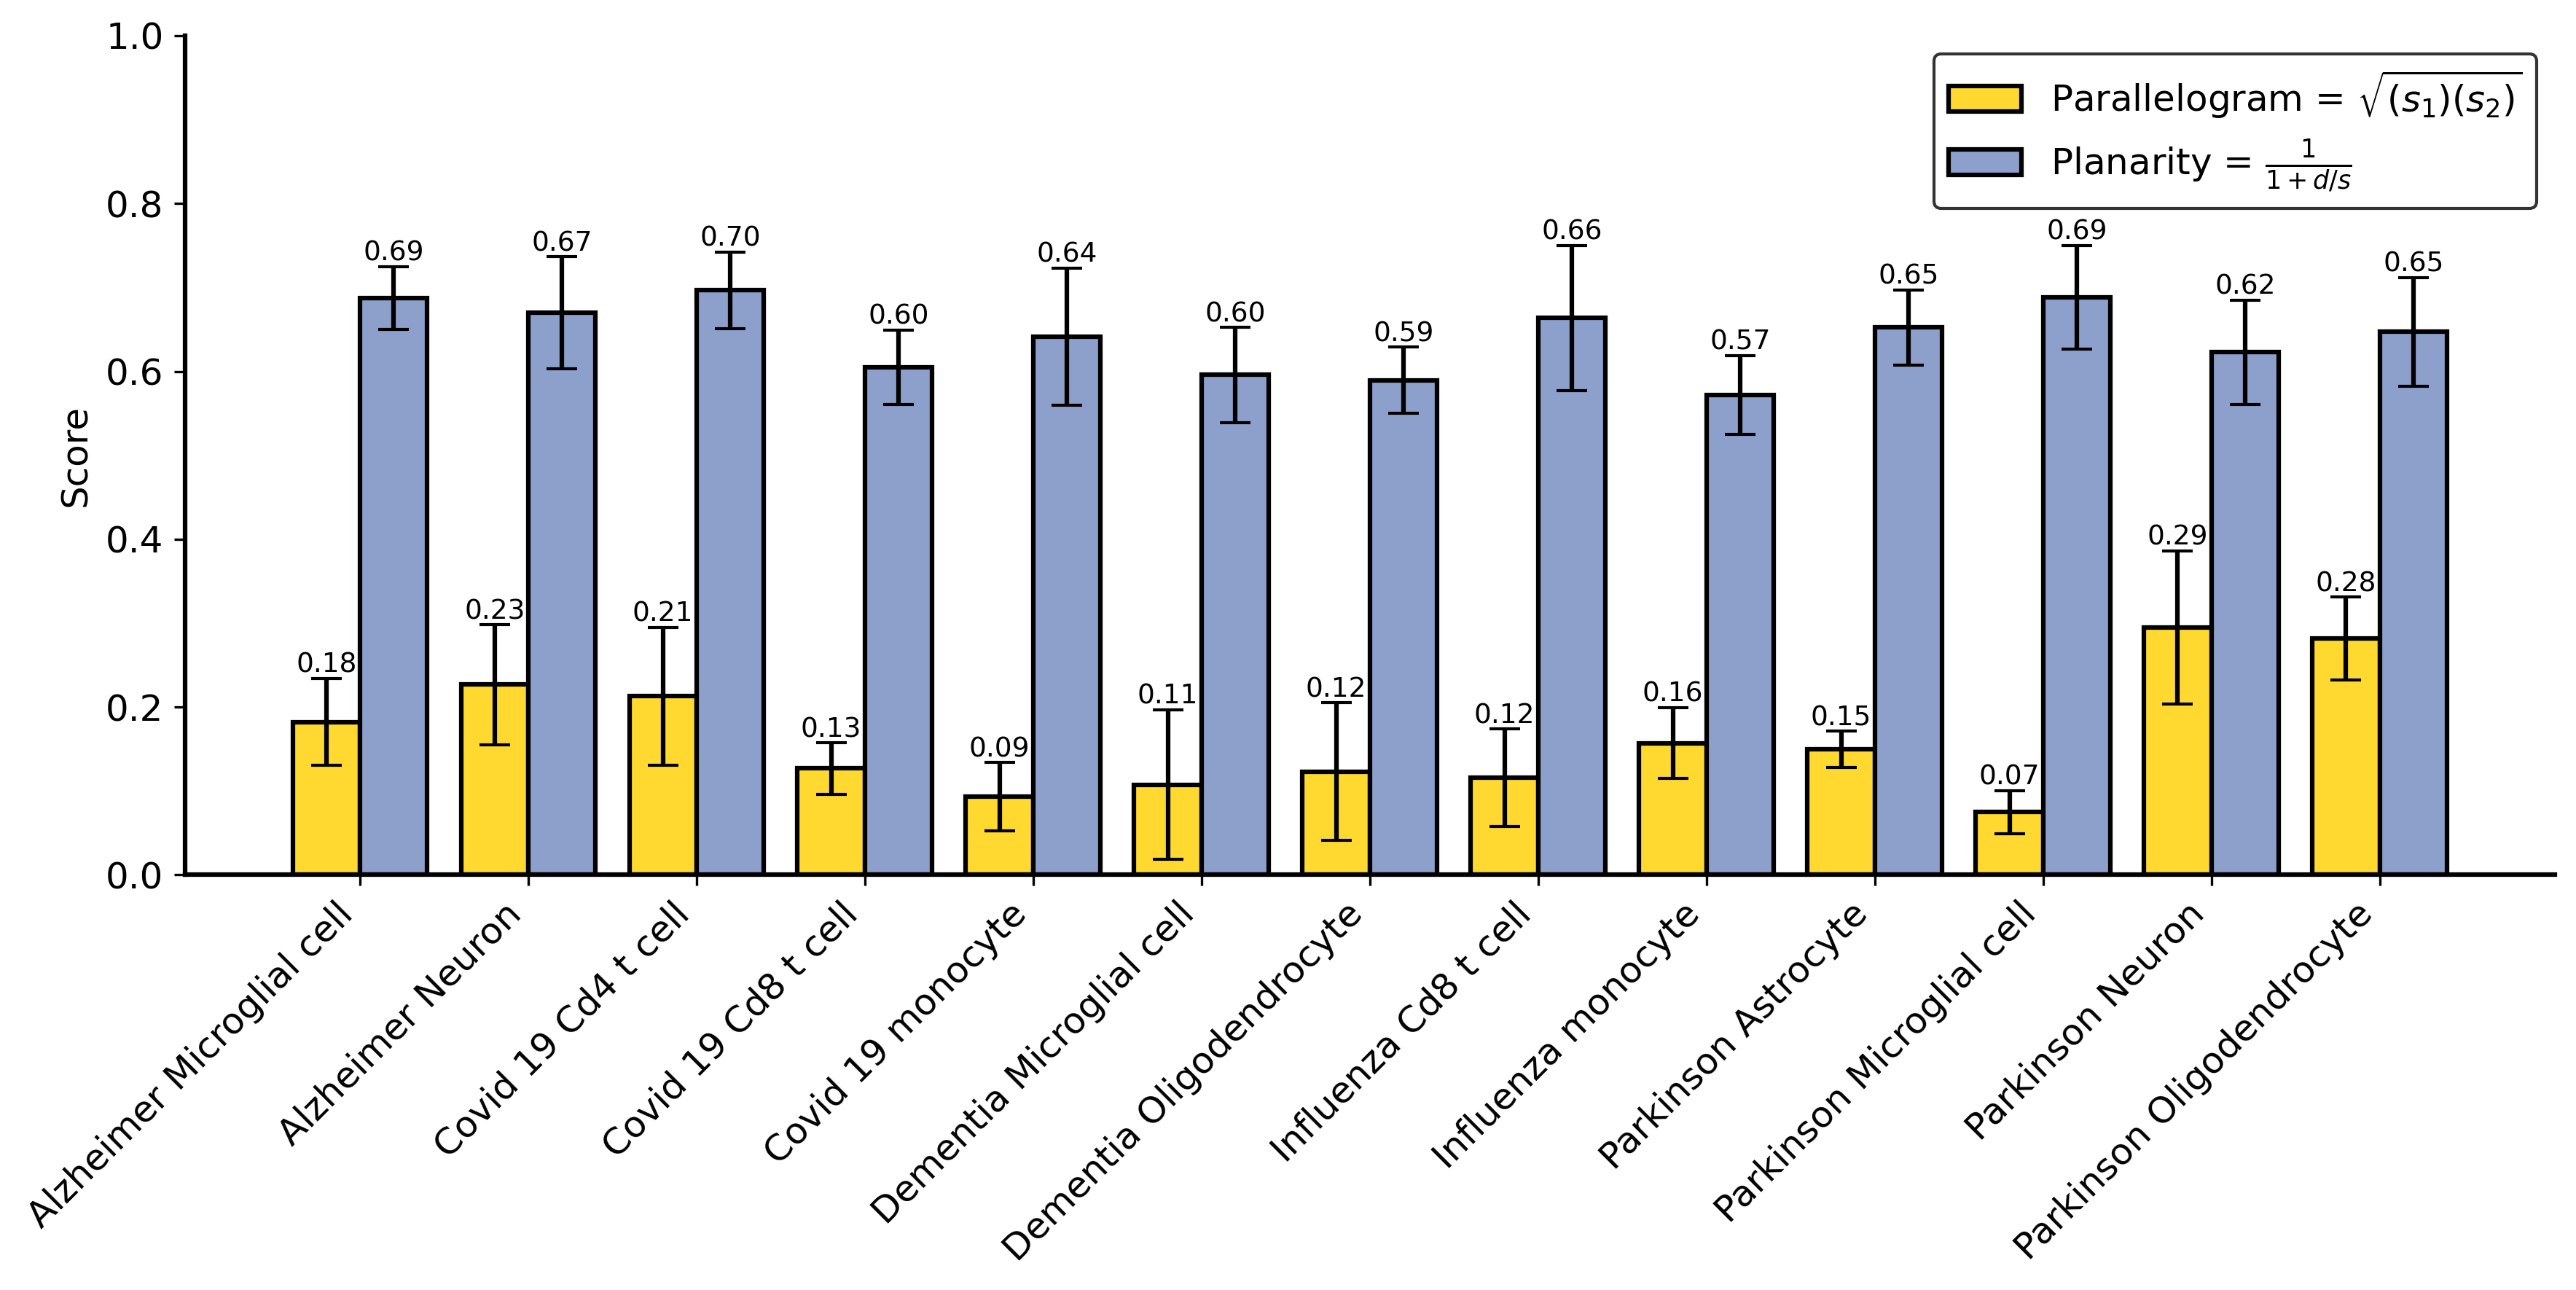

In [36]:
plot_df = sum_df.T.reset_index(names="disease_cellpair").melt(
    id_vars="disease_cellpair", var_name=["stat","metric"], value_name="score"
)

# separate mean and std
mean_df = plot_df[plot_df["stat"]=="mean"].rename(columns={"score":"mean"})
std_df = plot_df[plot_df["stat"]=="std"].rename(columns={"score":"std"})
plot_df = pd.merge(mean_df, std_df, on=["disease_cellpair","metric"])

plt.figure(figsize=(12,6), dpi=300)
ax = plt.gca()
width = 0.4
x = np.arange(len(plot_df["disease_cellpair"].unique()))

palette = sns.color_palette("Set2_r", n_colors=2)
metric_labels = {
    "parallelogram": r"Parallelogram = $\sqrt{(s_1)(s_2)}$",
    "planarity": r"Planarity = $\frac{1}{1+d/s}$",
}

for i, metric in enumerate(plot_df["metric"].unique()):
    subset = plot_df[plot_df["metric"]==metric]
    bars = ax.bar(
        x + i*width,
        subset["mean"],
        width=width,
        yerr=subset["std"],
        capsize=5,
        label=metric_labels[metric],
        color=palette[i],
        linewidth=1.5,
        edgecolor='k',
        zorder=-10
    )
    for idx, (bar, val) in enumerate(zip(bars, subset["mean"])):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + subset["std"].tolist()[idx],
            f"{val:.2f}",
            ha='center', va='bottom',
            fontsize=9,
        )

ax.set_ylabel("Score", fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(1.5)
ax.set_xticks(x + width/2)
#ax.set_ylim(0.37, 1)
ax.set_ylim(0, 1)
ax.set_xticklabels(plot_df["disease_cellpair"].drop_duplicates().apply(
    lambda x: ' '.join([word.capitalize() for word in x.split('_')]).replace(" disease", "").replace("Classical ", "").replace(" positive alpha beta", "")),
                    rotation=45, fontsize=12, ha='right')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12, edgecolor='k')
plt.tight_layout()
plt.savefig("planarity_populations.png", dpi=300)
plt.show()
